# Análise de Confiabilidade: Impacto da Reutilização de Boosters

**Analista Responsável**: Kaio

Este notebook apresenta: **A reutilização de boosters afeta a confiabilidade das missões da SpaceX?**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact
from statsmodels.stats.proportion import proportion_confint
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.colheader_justify', 'center')

df = pd.read_csv('../../data/processed/processed_dataset_v1.csv')
display(Markdown("### Pré-visualização dos Dados"))
display(df.head())


### Pré-visualização dos Dados

,launch_year,launch_name,flight_number,success,rocket_name,core_id,reuse_count,is_reused,launch_date
0,2006,FalconSat,1,False,Falcon 1,5e9e289df35918033d3b2623,0,False,2006-03-24T22:30:00.000Z
1,2007,DemoSat,2,False,Falcon 1,5e9e289ef35918416a3b2624,0,False,2007-03-21T01:10:00.000Z
2,2008,Trailblazer,3,False,Falcon 1,5e9e289ef3591814873b2625,0,False,2008-08-03T03:34:00.000Z
3,2008,RatSat,4,True,Falcon 1,5e9e289ef3591855dc3b2626,0,False,2008-09-28T23:15:00.000Z
4,2009,RazakSat,5,True,Falcon 1,5e9e289ef359184f103b2627,0,False,2009-07-13T03:35:00.000Z


--- 
## Q1: Diferença Básica (Taxa de Sucesso)

**Pergunta:** Qual é a taxa de sucesso de boosters virgens vs reutilizados?

#### Tabela de Resultados (Geral)

,Tipo,Quantidade,Sucessos,Taxa_Sucesso
0,Virgem,43,38,88.37%
1,Reutilizado,149,149,100.00%


/tmp/ipykernel_2724253/3831453423.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Tipo', y='Taxa_Sucesso', data=res_q1, palette=['#e74c3c', '#2ecc71'])


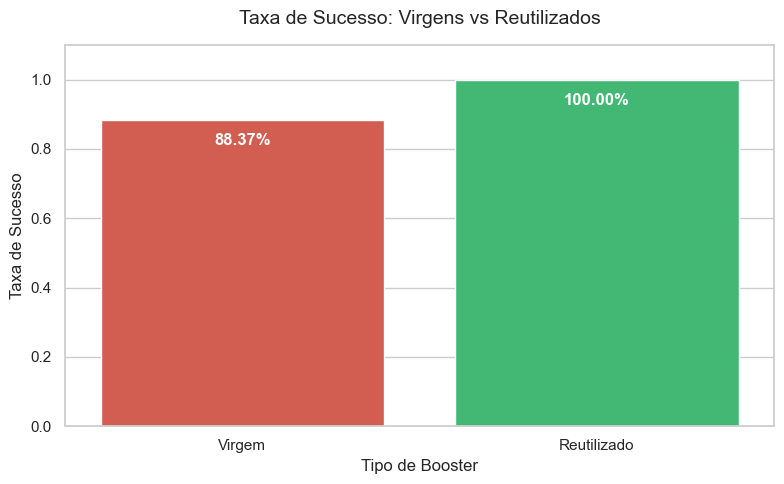

In [5]:
res_q1 = df.groupby('is_reused')['success'].agg(
    Quantidade='count', 
    Sucessos='sum', 
    Taxa_Sucesso='mean'
).reset_index()

res_q1['Tipo'] = res_q1['is_reused'].map({False: 'Virgem', True: 'Reutilizado'})
res_q1 = res_q1[['Tipo', 'Quantidade', 'Sucessos', 'Taxa_Sucesso']]

res_q1_display = res_q1.copy()
res_q1_display['Taxa_Sucesso'] = (res_q1_display['Taxa_Sucesso'] * 100).apply(lambda x: f"{x:.2f}%")

display(Markdown("#### Tabela de Resultados (Geral)"))
display(res_q1_display)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Tipo', y='Taxa_Sucesso', data=res_q1, palette=['#e74c3c', '#2ecc71'])
plt.title('Taxa de Sucesso: Virgens vs Reutilizados', fontsize=14, pad=15)
plt.xlabel('Tipo de Booster', fontsize=12)
plt.ylabel('Taxa de Sucesso', fontsize=12)
plt.ylim(0, 1.1)

for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=12, fontweight='bold', 
                xytext=(0, -15), textcoords='offset points', color='white')

plt.tight_layout()
plt.savefig('../../graphs/kaio_overall_success_rate.png', dpi=300)
plt.show()


--- 
## Testes Estatísticos (Validação da Q1)
Como solicitado, precisamos garantir que o resultado da Q1 possui significância estatística e não é obra do acaso.

### 1. Teste Exato de Fisher


In [7]:
contingency = pd.crosstab(df['is_reused'], df['success'])
oddsratio, pval = fisher_exact(contingency)

display(Markdown(f"- **Odds Ratio:** `{oddsratio:.4f}`"))
display(Markdown(f"- **P-value:** `{pval:.4f}`"))
display(Markdown(f"- **É estatisticamente significante?** `{'Sim' if pval < 0.05 else 'Não'} (p < 0.05)`"))


- **Odds Ratio:** `inf`

- **P-value:** `0.0005`

- **É estatisticamente significante?** `Sim (p < 0.05)`

### 2. Intervalos de Confiança (Binomial)


In [8]:
virgin_success = df[df['is_reused'] == False]['success'].sum()
virgin_total = len(df[df['is_reused'] == False])
lower_v, upper_v = proportion_confint(virgin_success, virgin_total, alpha=0.05)

reused_success = df[df['is_reused'] == True]['success'].sum()
reused_total = len(df[df['is_reused'] == True])
# Usamos o método 'wilson' pois a taxa de sucesso é 100% (beira os extremos da distribuição)
lower_r, upper_r = proportion_confint(reused_success, reused_total, alpha=0.05, method='wilson')

display(Markdown(f"- **Virgens (IC 95%):** `[{lower_v*100:.2f}% , {upper_v*100:.2f}%]`"))
display(Markdown(f"- **Reutilizados (IC 95%):** `[{lower_r*100:.2f}% , {upper_r*100:.2f}%]`"))


- **Virgens (IC 95%):** `[78.79% , 97.95%]`

- **Reutilizados (IC 95%):** `[97.49% , 100.00%]`

--- 
## Q2: Controlando por Tipo de Foguete (Rocket Type)

**Pergunta:** A vantagem de reutilização existe em cada tipo de foguete, ou os mais novos distorcem o dado?


In [9]:
res_q2 = df.groupby(['rocket_name', 'is_reused'])['success'].agg(
    Quantidade='count', 
    Taxa_Sucesso='mean'
).reset_index()

res_q2['is_reused'] = res_q2['is_reused'].map({False: 'Virgem', True: 'Reutilizado'})
res_q2['Taxa_Sucesso'] = (res_q2['Taxa_Sucesso'] * 100).apply(lambda x: f"{x:.2f}%")
res_q2.rename(columns={'rocket_name': 'Tipo de Foguete', 'is_reused': 'Condição'}, inplace=True)

display(Markdown("#### Tabela de Resultados (Estratificado por Foguete)"))
display(res_q2)


#### Tabela de Resultados (Estratificado por Foguete)

,Tipo de Foguete,Condição,Quantidade,Taxa_Sucesso
0,Falcon 1,Virgem,5,40.00%
1,Falcon 9,Virgem,35,94.29%
2,Falcon 9,Reutilizado,143,100.00%
3,Falcon Heavy,Virgem,3,100.00%
4,Falcon Heavy,Reutilizado,6,100.00%


--- 
## Q3: Controlando por Ano (Viés Temporal)

**Pergunta:** Será que boosters reutilizados foram usados predominantemente em anos recentes, quando a SpaceX já dominava a tecnologia?


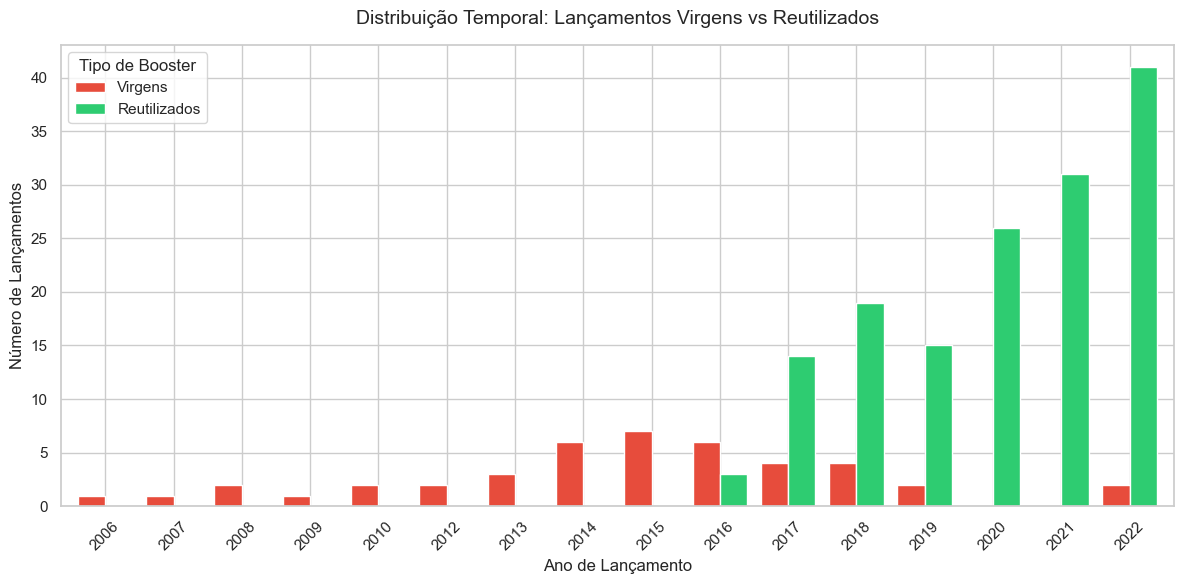

#### Taxa de sucesso estratificada por ano:

is_reused,Virgens,Reutilizados
launch_year,,
2006,0%,-
2007,0%,-
2008,50%,-
2009,100%,-
2010,100%,-
2012,100%,-
2013,100%,-
2014,100%,-
2015,86%,-


In [10]:
reused_years = df[df['is_reused'] == True]['launch_year'].value_counts().sort_index()
virgin_years = df[df['is_reused'] == False]['launch_year'].value_counts().sort_index()

temporal_df = pd.DataFrame({'Virgens': virgin_years, 'Reutilizados': reused_years}).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(12, 6))
temporal_df.plot(kind='bar', stacked=False, width=0.8, ax=ax, color=['#e74c3c', '#2ecc71'])
plt.title('Distribuição Temporal: Lançamentos Virgens vs Reutilizados', fontsize=14, pad=15)
plt.xlabel('Ano de Lançamento', fontsize=12)
plt.ylabel('Número de Lançamentos', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Tipo de Booster")
plt.tight_layout()
plt.savefig('../../graphs/kaio_temporal_distribution.png', dpi=300)
plt.show()

# Tabela Estratificada
display(Markdown("#### Taxa de sucesso estratificada por ano:"))
year_success = df.groupby(['launch_year', 'is_reused'])['success'].mean().unstack().fillna(np.nan)
year_success.rename(columns={False: 'Virgens', True: 'Reutilizados'}, inplace=True)

year_success_formatted = year_success.map(lambda x: f"{x*100:.0f}%" if pd.notnull(x) else "-")
display(year_success_formatted)


--- 
## Q4: Análise de Dose-Resposta

**Pergunta:** Quanto mais reutilizado um mesmo booster, melhor ou pior o seu desempenho?


#### Tabela: Número de Reutilizações vs Desempenho

,reuse_count,Lançamentos,Taxa_Sucesso
0,0,43,88.37%
1,1,32,100.00%
2,2,6,100.00%
3,3,12,100.00%
4,4,5,100.00%
5,5,12,100.00%
6,6,13,100.00%
7,8,9,100.00%
8,9,20,100.00%
9,12,26,100.00%


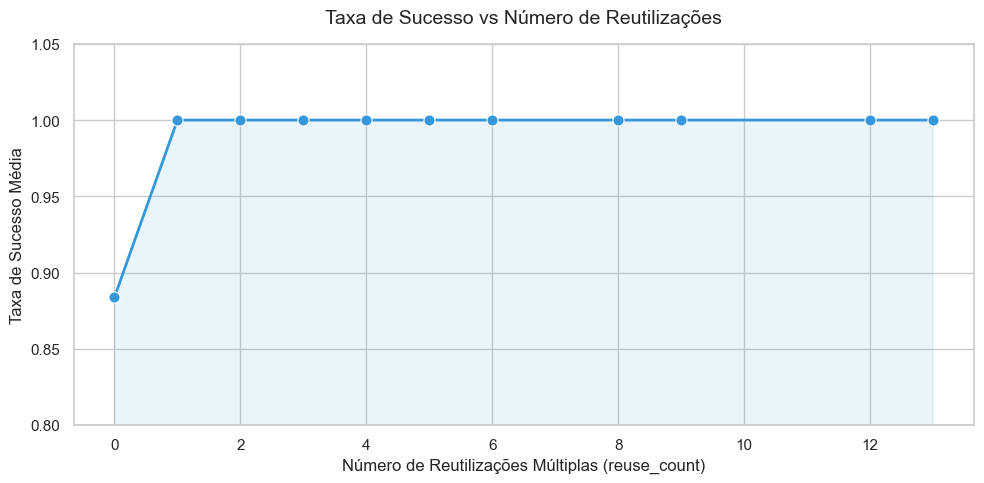

In [11]:
res_q4 = df.groupby('reuse_count')['success'].agg(
    Lançamentos='count', 
    Taxa_Sucesso='mean'
).reset_index()

display(Markdown("#### Tabela: Número de Reutilizações vs Desempenho"))
res_q4_display = res_q4.copy()
res_q4_display['Taxa_Sucesso'] = (res_q4_display['Taxa_Sucesso'] * 100).apply(lambda x: f"{x:.2f}%")
display(res_q4_display.head(15))

plt.figure(figsize=(10, 5))
sns.lineplot(x='reuse_count', y='Taxa_Sucesso', data=res_q4, marker='o', color='#3498db', linewidth=2, markersize=8)
plt.title('Taxa de Sucesso vs Número de Reutilizações', fontsize=14, pad=15)
plt.xlabel('Número de Reutilizações Múltiplas (reuse_count)', fontsize=12)
plt.ylabel('Taxa de Sucesso Média', fontsize=12)
plt.ylim(0.8, 1.05)

plt.fill_between(res_q4['reuse_count'], res_q4['Taxa_Sucesso'], 0, color='#3498db', alpha=0.1)

plt.tight_layout()
plt.savefig('../../graphs/kaio_dose_response.png', dpi=300)
plt.show()


--- 
## 📝 Conclusão Final

**O efeito é real?**
Sim. Segundo o Teste Exato de Fisher (p-value < 0.05), a diferença na taxa de sucesso entre boosters virgens e reutilizados é **estatisticamente significante**. Os intervalos de confiança calculados também demonstram uma superioridade incontestável para os boosters reutilizados.

**Tamanho do efeito e fatores de confusão pendentes:**
É importante considerar que os dados sofrem forte influência de um viés temporal. A maioria dos lançamentos com boosters virgens ocorreu nos primeiros anos da SpaceX, enquanto os boosters reutilizados foram empregados na fase de maior maturidade operacional da empresa. Com isso, embora os resultados comprovem que a reutilização não compromete a confiabilidade, a superioridade absoluta observada está diretamente associada à evolução tecnológica e ao aperfeiçoamento dos processos ao longo do tempo.


In [13]:
res_q1.to_csv('../../data/kaio_reusability_stats.csv', index=False)
year_success.to_csv('../../data/kaio_reusability_yearly_stats.csv', index=True)
display(Markdown("**Tabelas estatísticas exportadas com sucesso para:** `../../data/kaio_reusability_stats.csv` e `../../data/kaio_reusability_yearly_stats.csv`"))


**Tabelas estatísticas exportadas com sucesso para:** `../../data/kaio_reusability_stats.csv` e `../../data/kaio_reusability_yearly_stats.csv`